In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

In [6]:
file_path = "statistics_practice_dataset_2000.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2000, 16)


,EmployeeID,Age,Gender,Department,City,ExperienceYears,AnnualSalary,PerformanceScore,WeeklyHours,ProjectsCompleted,SatisfactionScore,CommuteKm,BMI,MonthlySalesK,DiscountPercent,JoinDate
0,1,31,Male,Sales,Mumbai,10,518415,73,37.3,1,7.3,1.0,29.2,61.88,20,2022-05-09
1,2,34,Male,IT,Kolkata,11,1532171,88,40.4,5,9.4,11.1,28.9,483.15,20,2020-09-12
2,3,40,Female,Marketing,Chennai,21,571512,73,35.1,3,8.0,1.3,25.9,80.10,10,2020-11-29
3,4,29,Female,IT,Mumbai,8,1111900,79,39.6,4,9.1,9.8,24.1,502.63,30,2020-04-24
4,5,33,Male,HR,Chennai,12,2067096,77,43.4,7,8.6,9.3,29.6,234.04,20,2022-03-28


In [7]:
required_columns = [
    "ExperienceYears",
    "AnnualSalary",
    "Department",
    "Gender",
    "City"
]

print(df[required_columns].head())

   ExperienceYears  AnnualSalary Department  Gender     City
0               10        518415      Sales    Male   Mumbai
1               11       1532171         IT    Male  Kolkata
2               21        571512  Marketing  Female  Chennai
3                8       1111900         IT  Female   Mumbai
4               12       2067096         HR    Male  Chennai


In [8]:
print("Missing Values:")
print(df[required_columns].isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
ExperienceYears    0
AnnualSalary       0
Department         0
Gender             0
City               0
dtype: int64

Duplicate Rows: 0


In [9]:
statistics = df[
    ["ExperienceYears", "AnnualSalary"]
].describe()

statistics

,ExperienceYears,AnnualSalary
count,2000.000000,2.000000e+03
mean,11.545500,1.087100e+06
std,7.589185,1.024491e+06
min,0.000000,2.500000e+05
25%,6.000000,6.619598e+05
50%,11.000000,9.066290e+05
75%,17.000000,1.241282e+06
max,37.000000,2.060328e+07


In [10]:
experience_salary_corr = df[
    ["ExperienceYears", "AnnualSalary"]
].corr()

print(experience_salary_corr)

                 ExperienceYears  AnnualSalary
ExperienceYears         1.000000      0.015162
AnnualSalary            0.015162      1.000000


In [11]:
age_experience_corr = df[
    ["Age", "ExperienceYears"]
].corr()

print(age_experience_corr)

                      Age  ExperienceYears
Age              1.000000         0.981024
ExperienceYears  0.981024         1.000000


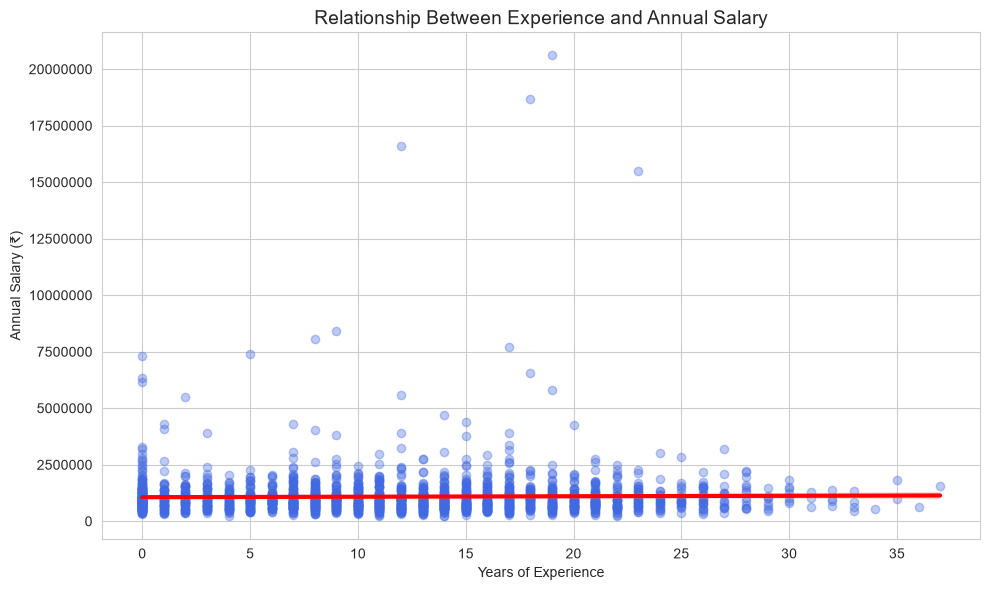

In [12]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="ExperienceYears",
    y="AnnualSalary",
    scatter_kws={
        "alpha": 0.35,
        "color": "royalblue"
    },
    line_kws={
        "color": "red",
        "linewidth": 3
    }
)

plt.title(
    "Relationship Between Experience and Annual Salary",
    fontsize=14
)
plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary (₹)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

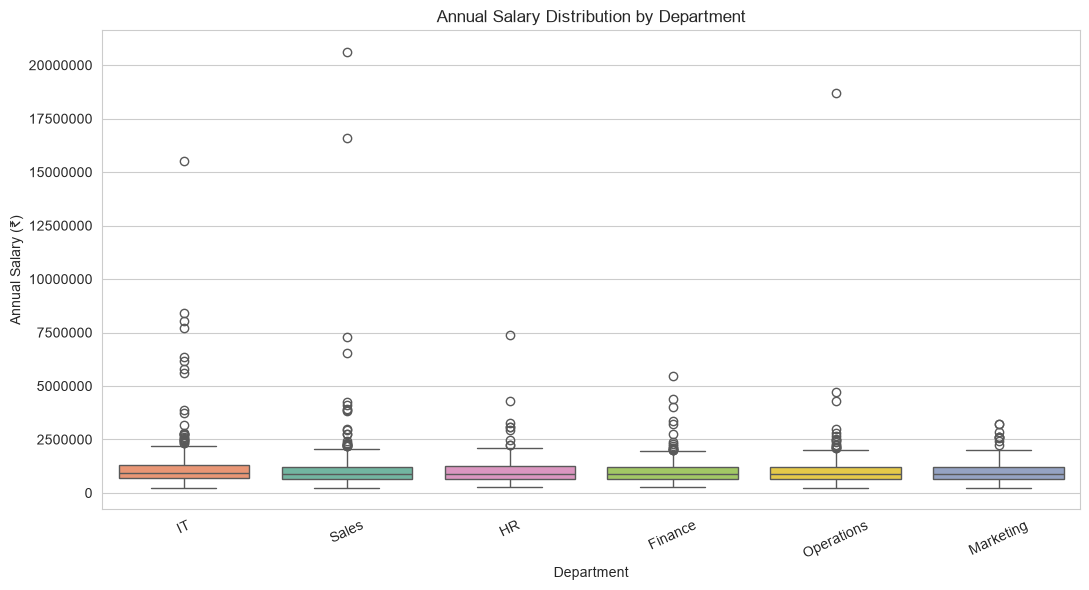

In [13]:
plt.figure(figsize=(11, 6))

order = (
    df.groupby("Department")["AnnualSalary"]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=df,
    x="Department",
    y="AnnualSalary",
    order=order,
    hue="Department",
    palette="Set2",
    legend=False
)

plt.title("Annual Salary Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Annual Salary (₹)")
plt.xticks(rotation=25)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

In [14]:
X_simple = df[["ExperienceYears"]]
y = df["AnnualSalary"]

X_train_simple, X_test_simple, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(
    X_train_simple,
    y_train
)

simple_predictions = simple_model.predict(
    X_test_simple
)

In [15]:
simple_mae = mean_absolute_error(
    y_test,
    simple_predictions
)

simple_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        simple_predictions
    )
)

simple_r2 = r2_score(
    y_test,
    simple_predictions
)

print("Experience Coefficient:",
      round(simple_model.coef_[0], 2))

print("MAE:", round(simple_mae, 2))
print("RMSE:", round(simple_rmse, 2))
print("R² Score:", round(simple_r2, 4))

Experience Coefficient: 4122.91
MAE: 436013.47
RMSE: 660035.6
R² Score: -0.0142


In [16]:
features = [
    "ExperienceYears",
    "Department",
    "Gender",
    "City"
]

categorical_features = [
    "Department",
    "Gender",
    "City"
]

X = df[features]
y = df["AnnualSalary"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Rows:", X_train.shape[0])
print("Testing Rows:", X_test.shape[0])

Training Rows: 1600
Testing Rows: 400


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [19]:
regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

regression_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['ExperienceYears','Department','Gender','City']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output

In [20]:
y_pred = regression_pipeline.predict(X_test)

prediction_results = pd.DataFrame({
    "Actual_Salary": y_test.values,
    "Predicted_Salary": y_pred
})

prediction_results.head(10)

,Actual_Salary,Predicted_Salary
0,1041321,1.042186e+06
1,1170201,1.141806e+06
2,1075092,1.043911e+06
3,1025818,1.128330e+06
4,1853259,9.558031e+05
5,3220729,1.115036e+06
6,1056444,1.318703e+06
7,1194838,1.157681e+06
8,600915,1.089871e+06
9,585101,1.153606e+06


In [21]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

MAE: 435798.7
RMSE: 660804.81
R² Score: -0.0166


In [22]:
feature_names = (
    regression_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    regression_pipeline
    .named_steps["model"]
    .coef_
)

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

experience_result = coefficient_table[
    coefficient_table["Feature"]
    .str.contains("ExperienceYears")
]

experience_result

,Feature,Coefficient
14,remainder__ExperienceYears,4370.084729


In [23]:
bins = [
    -1, 4, 9, 14,
    19, 24, 29,
    34, 100
]

labels = [
    "0–4", "5–9", "10–14",
    "15–19", "20–24",
    "25–29", "30–34", "35+"
]

df["ExperienceGroup"] = pd.cut(
    df["ExperienceYears"],
    bins=bins,
    labels=labels
)

salary_progression = (
    df.groupby(
        "ExperienceGroup",
        observed=True
    )["AnnualSalary"]
    .agg(["count", "mean", "median"])
    .round(2)
)

salary_progression

,count,mean,median
ExperienceGroup,,,
0–4,409,1089211.23,933527.0
5–9,426,1068277.12,917931.5
10–14,475,1031919.68,884811.0
15–19,363,1192557.40,898551.0
20–24,225,1063282.11,857907.0
25–29,79,1100719.08,980599.0
30–34,19,1020087.42,981836.0
35+,4,1247435.25,1258557.5


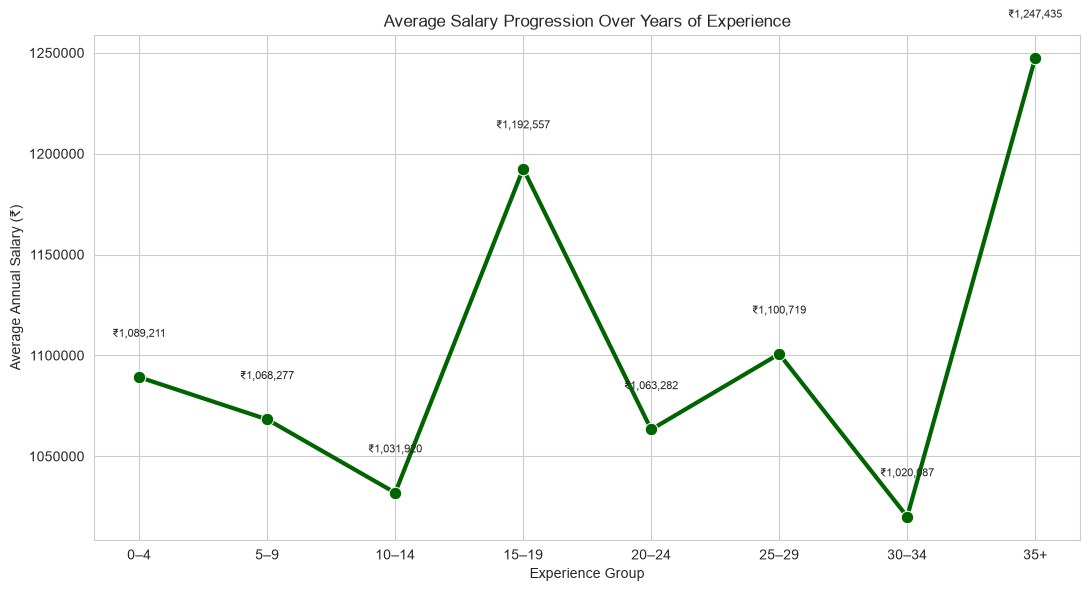

In [24]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=salary_progression.reset_index(),
    x="ExperienceGroup",
    y="mean",
    marker="o",
    linewidth=3,
    markersize=9,
    color="darkgreen"
)

for index, value in enumerate(
    salary_progression["mean"]
):
    plt.text(
        index,
        value + 20000,
        f"₹{value:,.0f}",
        ha="center",
        fontsize=8
    )

plt.title(
    "Average Salary Progression Over Years of Experience"
)
plt.xlabel("Experience Group")
plt.ylabel("Average Annual Salary (₹)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

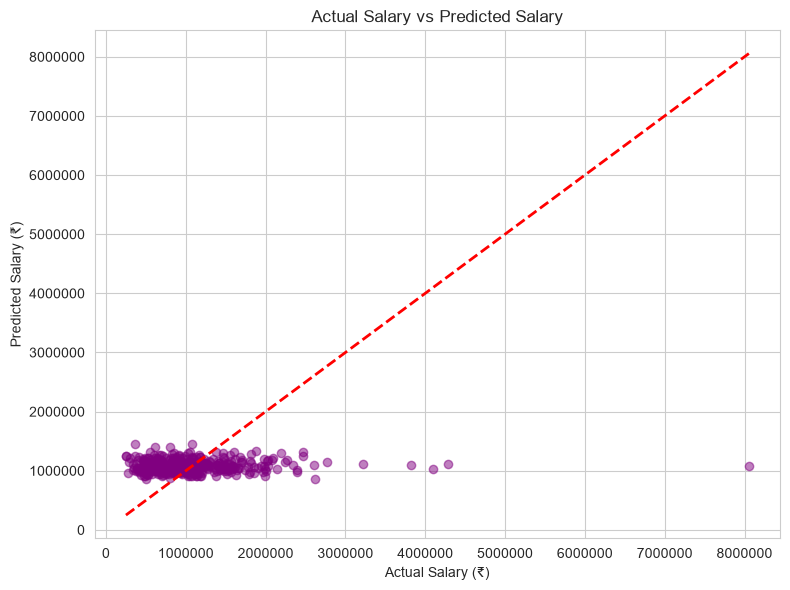

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color="purple"
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Actual Salary vs Predicted Salary")
plt.xlabel("Actual Salary (₹)")
plt.ylabel("Predicted Salary (₹)")
plt.ticklabel_format(style="plain")
plt.tight_layout()
plt.show()

In [26]:
"""The analysis found an extremely weak positive correlation of 0.0152 between experience and annual salary. After controlling for department, gender and city, the regression coefficient suggested an approximate increase of ₹4,370 per additional year of experience. However, the adjusted model produced an R² score of −0.0166, showing that these variables could not reliably explain salary variation. Therefore, experience does not have a meaningful independent impact on salary in this dataset. Other variables such as job level, education, skills and role may be required for a more accurate salary model."""

'The analysis found an extremely weak positive correlation of 0.0152 between experience and annual salary. After controlling for department, gender and city, the regression coefficient suggested an approximate increase of ₹4,370 per additional year of experience. However, the adjusted model produced an R² score of −0.0166, showing that these variables could not reliably explain salary variation. Therefore, experience does not have a meaningful independent impact on salary in this dataset. Other variables such as job level, education, skills and role may be required for a more accurate salary model.'